In [2]:
import re
import pandas as pd

In [3]:
file=open('WhatsApp Chat with Ha👻 Ha😂 Ha😇.txt','r',encoding='utf-8')

In [4]:
data=file.read()

In [101]:
#print(data)

In [5]:
pattern = r"^\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s(?:am|pm)\s-\s"

In [6]:
msgs = re.split(pattern, data, flags=re.MULTILINE)[1:]
#print(msgs)

In [7]:
date=re.findall(pattern,data,flags=re.M)
clean_dates = [d.replace('\u202f', ' ') for d in date]
#clean_dates

In [8]:
df=pd.DataFrame({'user_message':msgs,'message_date':clean_dates})
df['message_date'] = df['message_date'].str.replace(' - ', '', regex=False).str.strip()
df['message_date']=pd.to_datetime(df['message_date'],format='%d/%m/%y, %I:%M %p')
df.rename(columns={'message_date':'date'},inplace=True)
df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. O...,2024-12-31 09:11:00
1,Mr. Shiii🥰👻 changed this group's icon\n,2024-12-31 09:11:00
2,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024-12-31 09:11:00
3,Mr. Shiii🥰👻 added you\n,2024-12-31 09:11:00
4,Mr. Shiii🥰👻: Come to college by 1:30 pm\n,2024-12-31 09:11:00


In [9]:
df.shape

(19901, 2)

In [10]:
users = []
messages = []
for message in df['user_message']:
    entry = re.split('^([\w\W]+?):\s', message, maxsplit=1)
    if len(entry) > 1:
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])
df['user'] = users
df['message'] = messages
df.drop(columns=['user_message'], inplace=True)
df.head()

,date,user,message
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n"
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n


In [11]:
df['year']=df['date'].dt.year

In [12]:
df['month']=df['date'].dt.month_name()

In [13]:
df['day']=df['date'].dt.day
df.head()

,date,user,message,year,month,day
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,December,31
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n,2024,December,31
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024,December,31
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n,2024,December,31
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n,2024,December,31


In [14]:
df['hour']=df['date'].dt.hour


In [15]:
df['minute']=df['date'].dt.minute

In [16]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,December,31,9,11
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n,2024,December,31,9,11
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024,December,31,9,11
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n,2024,December,31,9,11
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n,2024,December,31,9,11


In [17]:
 df[df['user']=='Mr. Shiii🥰👻'].shape

(5435, 8)

In [18]:
words=[]
for msg in df['message']:
    words.extend(msg.split())

In [19]:
len(words)

72630

In [46]:
pip install urlextract


   ---------------------------------------- 2/2 [urlextract]

Note: you may need to restart the kernel to use updated packages.


In [20]:
from urlextract import  URLExtract
ext=URLExtract()
urls=ext.find_urls('lets have url stackoverflow.com as an example google.com , http://facebook.com')
urls

['stackoverflow.com', 'google.com', 'http://facebook.com']

In [21]:
links=[]
for msg in df['message']:
    links.extend(ext.find_urls(msg))

In [22]:
len(links)

201

In [23]:
x=df['user'].value_counts().head()

C:\Users\manas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129392 (\N{SMILING FACE WITH SMILING EYES AND THREE HEARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\manas\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


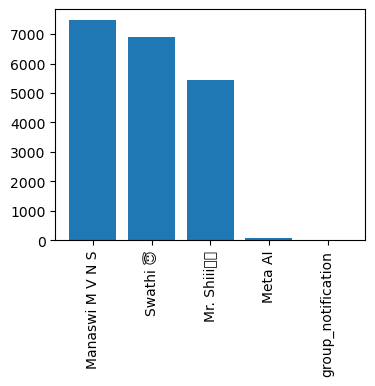

In [24]:
import matplotlib.pyplot as plt
name=x.index
count=x.values
plt.figure(figsize=(4,3))
plt.bar(name,count)
plt.xticks(rotation='vertical')
plt.show()

In [25]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index()

,user,count
0,Manaswi M V N S,37.50
1,Swathi 😇,34.68
2,Mr. Shiii🥰👻,27.31
3,Meta AI,0.40
4,group_notification,0.11


In [26]:
temp=df[df['user']!='group_notification']
temp=temp[temp['message']!='<Media omitted>\n']

In [72]:
pip install telugu-stopwords

Note: you may need to restart the kernel to use updated packages.


In [124]:
from telugu_stopwords import tsw, rmtsw
telugu_sw = tsw()
stopwords = telugu_sw.get_stopwords(script="english")
# text='nenu ee roju chala happy ga unnanu'
# cleaned = rmtsw(text, script="english")
# print(cleaned)


In [125]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stopwords = set(stopwords).union(set(ENGLISH_STOP_WORDS))

In [126]:
import string
all_stopwords.update(['message', 'omitted', 'media', 'haa', 'kooda', 'aithe', 'ade', 'lo'])
words=[]
for msg in temp['message']:
    for word in msg.lower().split():
        clean_word = word.strip(string.punctuation)
        if clean_word and clean_word not in all_stopwords and len(clean_word) > 1:
            words.append(clean_word)
    words.extend(msg.split())

In [30]:
word=[]
for msg in df['message']:
    word.extend(msg.split())

In [31]:
from collections import Counter
pd.DataFrame(Counter(word).most_common(20))

,0,1
0,<Media,3549
1,omitted>,3549
2,lo,494
3,and,478
4,ga,403
5,to,382
6,Haa,381
7,a,362
8,ki,341
9,the,332


In [133]:
pip install emoji

   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 608.4/608.4 kB 11.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [32]:
import emoji
emojis=[]
for msg in df['message']:
    emojis.extend([c for c in msg if emoji.is_emoji(c)])

In [33]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,😂,766
1,😁,732
2,🤩,711
3,😅,505
4,🥳,451
...,...,...
284,🪚,1
285,✔,1
286,🚗,1
287,🏍,1


In [34]:
df['month_num']=df['date'].dt.month
df.head()

,date,user,message,year,month,day,hour,minute,month_num
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,December,31,9,11,12
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n,2024,December,31,9,11,12
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024,December,31,9,11,12
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n,2024,December,31,9,11,12
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n,2024,December,31,9,11,12


In [35]:
timeline=df.groupby(['year','month_num','month']).count()['message'].reset_index()

In [36]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i] + "-" + str(timeline['year'][i]))

In [37]:
timeline['time']=time
timeline

,year,month_num,month,message,time
0,2024,12,December,97,December-2024
1,2025,1,January,5977,January-2025
2,2025,2,February,1063,February-2025
3,2025,3,March,2819,March-2025
4,2025,4,April,1182,April-2025
5,2025,5,May,1302,May-2025
6,2025,6,June,818,June-2025
7,2025,7,July,3102,July-2025
8,2025,8,August,1544,August-2025
9,2025,9,September,373,September-2025


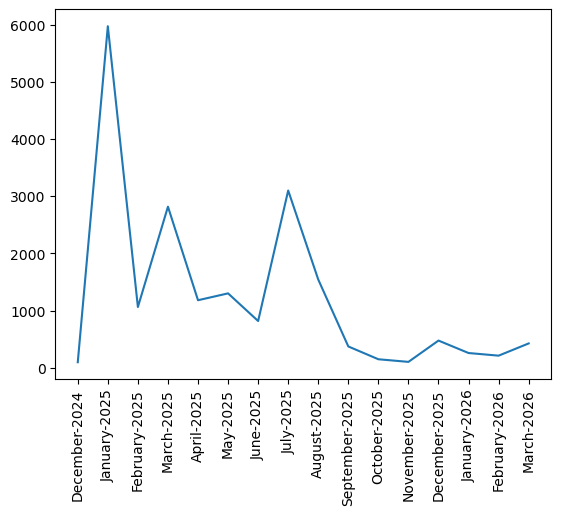

In [38]:
plt.plot(timeline['time'],timeline['message'])
plt.xticks(rotation='vertical')
plt.show()

In [39]:
df['only_date']=df['date'].dt.date
daily_timeline=df.groupby('only_date').count()['message'].reset_index()

(array([20089., 20148., 20209., 20270., 20332., 20393., 20454., 20513.]),
 [Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03'),
  Text(20209.0, 0, '2025-05'),
  Text(20270.0, 0, '2025-07'),
  Text(20332.0, 0, '2025-09'),
  Text(20393.0, 0, '2025-11'),
  Text(20454.0, 0, '2026-01'),
  Text(20513.0, 0, '2026-03')])

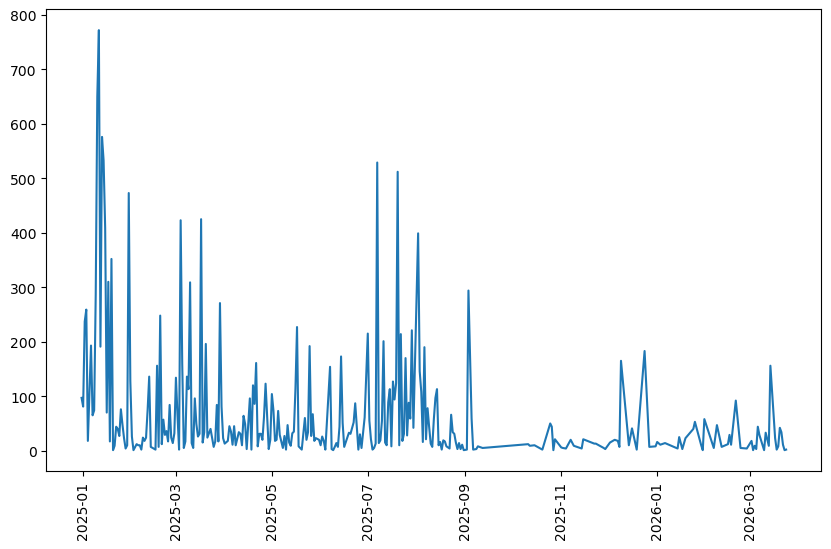

In [40]:
plt.figure(figsize=(10,6))
plt.plot(daily_timeline['only_date'],daily_timeline['message'])
plt.xticks(rotation='vertical')

In [42]:
df['day_name']=df['date'].dt.day_name()
df.head()

,date,user,message,year,month,day,hour,minute,month_num,only_date,day_name
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,December,31,9,11,12,2024-12-31,Tuesday
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n,2024,December,31,9,11,12,2024-12-31,Tuesday
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024,December,31,9,11,12,2024-12-31,Tuesday
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n,2024,December,31,9,11,12,2024-12-31,Tuesday
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n,2024,December,31,9,11,12,2024-12-31,Tuesday


In [43]:
df['day_name'].value_counts()

day_name
Saturday     3537
Monday       3181
Friday       2859
Sunday       2756
Tuesday      2705
Thursday     2451
Wednesday    2412
Name: count, dtype: int64

In [44]:
df['month'].value_counts()

month
January      6235
March        3245
July         3102
August       1544
May          1302
February     1275
April        1182
June          818
December      573
September     373
October       149
November      103
Name: count, dtype: int64

In [45]:
df.head()

,date,user,message,year,month,day,hour,minute,month_num,only_date,day_name
0,2024-12-31 09:11:00,group_notification,Messages and calls are end-to-end encrypted. O...,2024,December,31,9,11,12,2024-12-31,Tuesday
1,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 changed this group's icon\n,2024,December,31,9,11,12,2024-12-31,Tuesday
2,2024-12-31 09:11:00,group_notification,"Mr. Shiii🥰👻 created group ""Ha👻 Ha😂 Ha😇""\n",2024,December,31,9,11,12,2024-12-31,Tuesday
3,2024-12-31 09:11:00,group_notification,Mr. Shiii🥰👻 added you\n,2024,December,31,9,11,12,2024-12-31,Tuesday
4,2024-12-31 09:11:00,Mr. Shiii🥰👻,Come to college by 1:30 pm\n,2024,December,31,9,11,12,2024-12-31,Tuesday


In [46]:
period = []

for hour in df['date'].dt.hour:
    start_suffix = "AM" if hour < 12 else "PM"
    start_h = hour % 12
    if start_h == 0: start_h = 12
    next_hour_24 = (hour + 1) % 24
    end_suffix = "AM" if next_hour_24 < 12 else "PM"
    end_h = next_hour_24 % 12
    if end_h == 0: end_h = 12
    period.append(f"{start_h} {start_suffix}-{end_h} {end_suffix}")

In [48]:
df['period']=period

In [49]:
df.sample(5)

,date,user,message,year,month,day,hour,minute,month_num,only_date,day_name,period
19080,2026-01-19 20:02:00,Swathi 😇,☺️ neeku hi cheppaalanipinchindappudu☺️☺️☺️\n,2026,January,19,20,2,1,2026-01-19,Monday,8 PM-9 PM
10128,2025-04-08 19:14:00,Manaswi M V N S,Yes yes\n,2025,April,8,19,14,4,2025-04-08,Tuesday,7 PM-8 PM
15123,2025-07-20 20:57:00,Mr. Shiii🥰👻,Em cheyali\n,2025,July,20,20,57,7,2025-07-20,Sunday,8 PM-9 PM
14108,2025-07-08 22:12:00,Manaswi M V N S,Labubu\n,2025,July,8,22,12,7,2025-07-08,Tuesday,10 PM-11 PM
16996,2025-08-04 23:48:00,Mr. Shiii🥰👻,\n,2025,August,4,23,48,8,2025-08-04,Monday,11 PM-12 AM


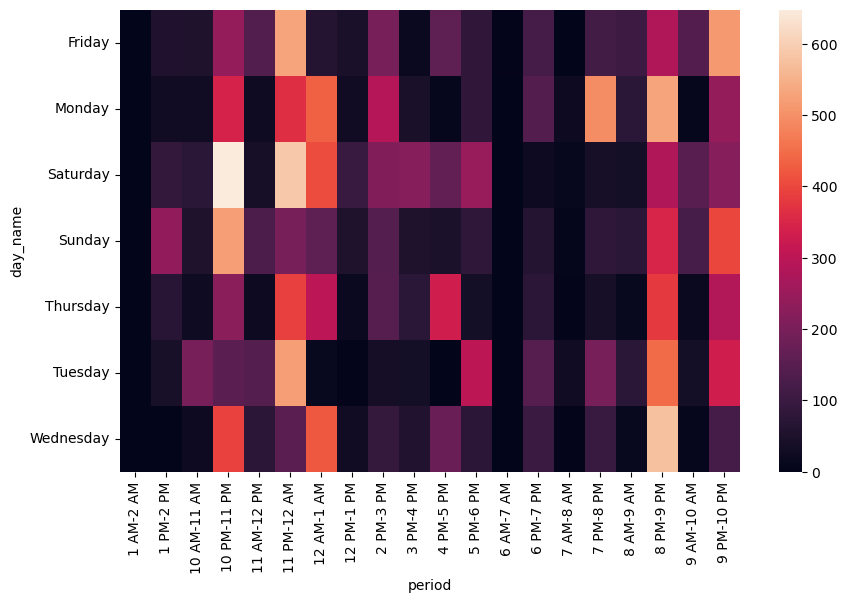

In [51]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.pivot_table(index='day_name',columns='period',values='message',aggfunc='count').fillna(0))
plt.yticks(rotation='horizontal')
plt.show()